# Preload Packages

In [2]:
# Limit number of cores
import os
os.nice(19)
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"

# Create logger
import logging
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

if not logger.hasHandlers():
    ch = logging.StreamHandler()
    formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
    ch.setFormatter(formatter)
    logger.addHandler(ch)

In [3]:
import pyccl as ccl
import matplotlib.pyplot as plt
import numpy as np

# Import galaxy alignment predictor
# Add root directory to path
import sys
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
root_dir = os.path.abspath(os.path.join(notebook_dir, '..'))
if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.galaxy_alignment_prediction_tool.predictor import galaxyAlignmentPredictor
from src.galaxy_alignment_prediction_tool.powerspectrum import powerSpectrum

# Set simulation settings

In [8]:
# Initialise ccl.Cosmology
import pyccl as ccl
ccl_cosmo = ccl.Cosmology(
    Omega_c=0.27,
    Omega_b=0.045,
    h=0.67,
    n_s=0.96,
    sigma8=0.8,
)

# Define redshifts at which to calculate estimators
redshift_list = np.arange(0, 2.1, 0.5)

# Define scales at which to calculate estimators
rp_array = np.geomspace(0.1, 200, 200)/ccl_cosmo['h']  # in Mpc
r_array = np.geomspace(0.1, 200, 200)/ccl_cosmo['h']  # in Mpc

# Pi_max for projection integrals
pi_max = 50.0/ccl_cosmo['h']  # in Mpc

# Example with included power spectra

2026-02-10 17:26:00,711 - __main__ - INFO - Initialising power spectrum splines for each redshift
100%|██████████| 5/5 [00:00<00:00, 6200.92it/s]
2026-02-10 17:26:00,714 - __main__ - INFO - Done. Splines stored in self.pk_splines_list
2026-02-10 17:26:00,714 - __main__ - INFO - Calculating estimators for each redshift and power spectrum type
100%|██████████| 5/5 [00:00<00:00, 50.20it/s]
2026-02-10 17:26:00,815 - __main__ - INFO - Done calculating estimators. Results stored in self.multipole_splines and self.projection_splines


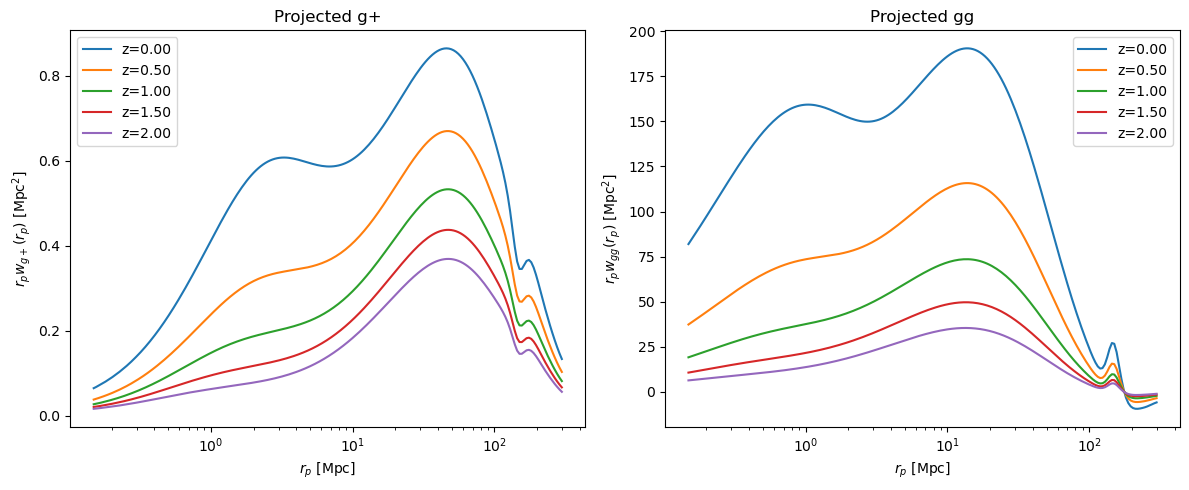

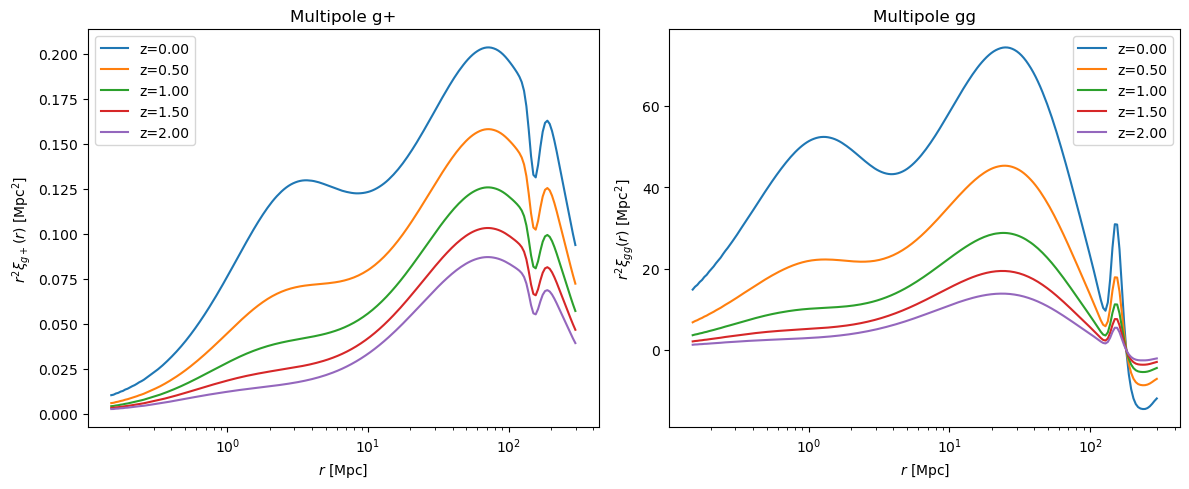

In [12]:
# Initialise class
predictor = galaxyAlignmentPredictor(
    cosmology=ccl_cosmo,
    redshift_list=redshift_list,
    logger=logger,
)

# This function internally compputes splines for g+ and gg power spectrum for each redshift
predictor.initialise_gp_gg_power_spectra_from_ccl(
    k_bounds=[1e-6, 1e3], # in 1/Mpc, chosen conservatively to cover all scales
    n_k=5000,
)

# This function function internally computes multipole and projection estimators
predictor.calculate_estimators(
    rp_support=rp_array,
    beta_shape=0, # No RSD, for example in real space
    beta_density=0, # No RSD, for example in real space
    pi_max=pi_max,
)

# Retrieve projection estimators as arrays
w_arr, xi_arr = predictor.return_all_estimators_as_arrays(
    rp_support=rp_array,
    r_support=r_array,
)

# Retrieve splines for projection estimators
# projection_splines is a list of lists of interp1d objects
# Outer list runs over redshifts, inner list over power spectrum types (g+, gg)
projection_splines = predictor.return_projection_splines()

# Retrieve splines for multipole estimators
# Same structure as projection_splines
multipole_splines = predictor.return_multipole_splines()

# Make example plot of w_g+ and w_gg as a function of rp for different redshifts
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
for idx_z, z in enumerate(redshift_list):
    w_gp_spline = projection_splines[idx_z][0]  # g+ projection spline
    w_gg_spline = projection_splines[idx_z][1]  # gg projection spline
    w_gp_at_rp = w_gp_spline(rp_array)
    w_gg_at_rp = w_gg_spline(rp_array)
    axs[0].semilogx(rp_array, rp_array*w_gp_at_rp, label=f'z={z:.2f}')
    axs[1].semilogx(rp_array, rp_array*w_gg_at_rp, label=f'z={z:.2f}')
axs[0].set_xlabel(r'$r_p$ [Mpc]')
axs[0].set_ylabel(r'$r_p w_{g+}(r_p)$ [Mpc$^2$]')
axs[0].set_title('Projected g+')
axs[0].legend()
axs[1].set_xlabel(r'$r_p$ [Mpc]')
axs[1].set_ylabel(r'$r_p w_{gg}(r_p)$ [Mpc$^2$]')
axs[1].set_title('Projected gg')
axs[1].legend()
plt.tight_layout()
plt.show()
plt.close()

# Make example plot of xi_g+ and xi_gg as a function of rp for different redshifts
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
for idx_z, z in enumerate(redshift_list):
    xi_gp_spline = multipole_splines[idx_z][0]  # g+ multipole spline
    xi_gg_spline = multipole_splines[idx_z][1]  # gg multipole spline
    xi_gp_at_r = xi_gp_spline(r_array)
    xi_gg_at_r = xi_gg_spline(r_array)
    axs[0].semilogx(r_array, r_array**2*xi_gp_at_r, label=f'z={z:.2f}')
    axs[1].semilogx(r_array, r_array**2*xi_gg_at_r, label=f'z={z:.2f}')
axs[0].set_xlabel(r'$r$ [Mpc]')
axs[0].set_ylabel(r'$r^2 \xi_{g+}(r)$ [Mpc$^2$]')
axs[0].set_title('Multipole g+')
axs[0].legend()
axs[1].set_xlabel(r'$r$ [Mpc]')
axs[1].set_ylabel(r'$r^2 \xi_{gg}(r)$ [Mpc$^2$]')
axs[1].set_title('Multipole gg')
axs[1].legend()
plt.tight_layout()
plt.show()
plt.close()

# Example with custom power spectra

In [14]:
# We need to create k_array and pk_array as np.ndarrays in the format (n_k, n_pk, n_redshifts). 
# We use here the vanilla g+ and gg obtained from the 3d matter power spectrum
k_array_single = np.geomspace(1e-5, 5e2, 1000)  # shape (n_k,)
k_array = np.tile(k_array_single, (len(redshift_list), 2, 1)).T
pk_input = np.zeros((len(k_array_single), 2, len(redshift_list)))  # shape (n_k, n_pk, n_redshifts)

# Fill pk_input with g+ and gg power spectra
powerSpectrumHandler = powerSpectrum()
for idx_z, z in enumerate(redshift_list):
    pkmm_ccl = powerSpectrumHandler.ccl_power_spectrum(
        cosmo=ccl_cosmo,
        k_input=k_array_single,
        redshift=z,
        pk_type='nonlinear_matter'
    )

    # Initialise power spectra
    pkgp = powerSpectrumHandler.convert_pk_matter_to_pk_gplus(
        pk_matter=pkmm_ccl,
        cosmo=ccl_cosmo,
        redshift=z
    )
    pkgg = powerSpectrumHandler.convert_pk_matter_to_pk_gg(
        pk_matter=pkmm_ccl,
        cosmo=ccl_cosmo,
        redshift=z,
        )

    pk_input[:, 0, idx_z] = pkgp
    pk_input[:, 1, idx_z] = pkgg

# Then, we initialise the power spectra in the predictor
predictor = galaxyAlignmentPredictor(
    cosmology=ccl_cosmo,
    redshift_list=redshift_list,
    logger=logger,
)
predictor.initialise_power_spectra(
    k_input=k_array,
    pk_input=pk_input,
    bessel_order =np.array([2, 0]),  # order 2 for g+, order 0 for gg
)

# The rest of the procedure is the same as above
predictor.calculate_estimators(
    rp_support=rp_array,
    beta_shape=0, # No RSD, for example in real space
    beta_density=0, # No RSD, for example in real space
    pi_max=pi_max,
)


# Retrieve projection estimators as arrays
w_arr, xi_arr = predictor.return_all_estimators_as_arrays(
    rp_support=rp_array,
    r_support=r_array,
)

# Retrieve splines for projection estimators
# projection_splines is a list of lists of interp1d objects
# Outer list runs over redshifts, inner list over power spectrum types (g+, gg)
projection_splines = predictor.return_projection_splines()

# Example: evaluate w_gp at rp = 10 Mpc/h for all redshifts
rp_eval = 10.0 / ccl_cosmo['h']  # in Mpc
for idx_z, z in enumerate(redshift_list):
    w_gp_spline = projection_splines[idx_z][0]  # g+ projection spline
    w_gp_at_rp = w_gp_spline(rp_eval)
    logger.info(f"w_gp at rp={rp_eval:.2f} Mpc for z={z:.2f} is {w_gp_at_rp:.4e} Mpc")

# Same for multipoles
multipole_splines = predictor.return_multipole_splines()
for idx_z, z in enumerate(redshift_list):
    xi_gg_spline = multipole_splines[idx_z][1]  # gg multipole spline
    xi_gg_at_r = xi_gg_spline(rp_eval)
    logger.info(f"xi_gg at r={rp_eval:.2f} Mpc for z={z:.2f} is {xi_gg_at_r:.4e} Mpc")

2026-01-21 14:54:02,262 - __main__ - INFO - Initialising power spectrum splines for each redshift
100%|██████████| 9/9 [00:00<00:00, 15605.10it/s]
2026-01-21 14:54:02,264 - __main__ - INFO - Done. Splines stored in self.pk_splines_list
2026-01-21 14:54:02,264 - __main__ - INFO - Calculating estimators for each redshift and power spectrum type
100%|██████████| 9/9 [00:00<00:00, 22.56it/s]
2026-01-21 14:54:02,664 - __main__ - INFO - Done calculating estimators. Results stored in self.multipole_splines and self.projection_splines
2026-01-21 14:54:02,665 - __main__ - INFO - w_gp at rp=14.93 Mpc for z=0.00 is 4.4406e-02 Mpc
2026-01-21 14:54:02,666 - __main__ - INFO - w_gp at rp=14.93 Mpc for z=0.25 is 3.7386e-02 Mpc
2026-01-21 14:54:02,666 - __main__ - INFO - w_gp at rp=14.93 Mpc for z=0.50 is 3.1851e-02 Mpc
2026-01-21 14:54:02,666 - __main__ - INFO - w_gp at rp=14.93 Mpc for z=0.75 is 2.7546e-02 Mpc
2026-01-21 14:54:02,666 - __main__ - INFO - w_gp at rp=14.93 Mpc for z=1.00 is 2.4170e-02 M